In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from src.constants import STATE_CONFIG
from src.datasources import glofas

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
STATE = "Adamawa"
cfg = STATE_CONFIG[STATE]

ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]
WET_MONTHS = [8, 9, 10, 11]
RP_LEVELS = [3, 4, 5]
MAX_LEADTIME = 16
FIGURES_DIR = "figures"

THRESH = cfg["glofas_thresh"]
ACTION_LT = cfg["glofas_leadtime_action"]
READINESS_LT = cfg["glofas_leadtime_readiness"]

assert THRESH is not None, "glofas_thresh must be set in STATE_CONFIG before running this notebook"
assert ACTION_LT is not None, "glofas_leadtime_action must be set in STATE_CONFIG before running"

triggers = {"Action": ACTION_LT}
if READINESS_LT is not None:
    triggers["Readiness"] = READINESS_LT

print(f"State           : {STATE}")
print(f"GloFAS threshold: {THRESH:,} m³/s")
print(f"Action leadtime : ≤{ACTION_LT} days")
print(f"Readiness lt    : {'≤' + str(READINESS_LT) + ' days' if READINESS_LT else 'not configured'}")

State           : Adamawa
GloFAS threshold: 3,132 m³/s
Action leadtime : ≤5 days
Readiness lt    : not configured


## Load data

In [3]:
# GloFAS reforecast ensemble
df_gf_rf = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_gf_rf["time"] = pd.to_datetime(df_gf_rf["time"])
df_gf_rf["valid_time"] = pd.to_datetime(df_gf_rf["valid_time"])
df_gf_rf = df_gf_rf[df_gf_rf["leadtime"] <= MAX_LEADTIME]

# GloFAS reanalysis (used as leadtime=0)
df_gf_ra = glofas.load_glofas_reanalysis(cfg["glofas_station"])
df_gf_ra["time"] = pd.to_datetime(df_gf_ra["time"])

# Trigger matrix — canonical Floodscan flood year flags from notebook 08
trigger_matrix_blob = f"ds-aa-nga-flooding/processed/trigger_matrix/{STATE.lower()}_trigger_matrix.parquet"
df_trig = stratus.load_parquet_from_blob(trigger_matrix_blob)

all_fs_years = set(df_trig["year"])
fs_event_years = {
    rp: set(df_trig[df_trig[f"fs_{rp}yr"] == 1]["year"])
    for rp in RP_LEVELS
}

for rp in RP_LEVELS:
    print(f"Floodscan {rp}-yr RP event years: {sorted(fs_event_years[rp])}")

Floodscan 3-yr RP event years: [1998, 1999, 2003, 2012, 2015, 2018, 2019, 2022, 2023]
Floodscan 4-yr RP event years: [1999, 2012, 2015, 2018, 2022, 2023]
Floodscan 5-yr RP event years: [1999, 2012, 2015, 2022, 2023]


## Prepare combined GloFAS signal

GloFAS reanalysis is treated as leadtime=0 — it represents the discharge observation on each day
with no forecast horizon. It is concatenated with the ensemble-mean reforecast at leadtimes 1–16
to form a unified signal.

Evaluation is restricted to years present in the reforecast dataset to keep the denominator
consistent (reanalysis-only years would have no forecast signal beyond lt=0).

Wet-season annual max is computed per (year, leadtime), then cumulative max is taken across
leadtimes within each year. This means `cum_max` at leadtime lt is the highest signal seen
at any leadtime ≤ lt — a year is activated the first time `cum_max` crosses the threshold.

In [4]:
# Reforecast: ensemble mean per (valid_time, leadtime)
df_rf_mean = (
    df_gf_rf.groupby(["valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
)

# Reanalysis: reshape to match reforecast schema with leadtime=0
df_ra_lt0 = df_gf_ra.rename(columns={"time": "valid_time"})[["valid_time", "dis24"]].copy()
df_ra_lt0["leadtime"] = 0

# Union of reforecast years — evaluation denominator
rf_years = set(df_rf_mean["valid_time"].dt.year.unique())
print(f"Reforecast years: {min(rf_years)}–{max(rf_years)} ({len(rf_years)} years)")

# Combine and filter to wet season within reforecast window
df_all = pd.concat([df_ra_lt0, df_rf_mean], ignore_index=True)
df_wet = df_all[
    df_all["valid_time"].dt.month.isin(WET_MONTHS)
    & df_all["valid_time"].dt.year.isin(rf_years)
].copy()
df_wet["year"] = df_wet["valid_time"].dt.year

# Wet-season annual max per (year, leadtime), then cumulative max across leadtimes
df_annual = (
    df_wet.groupby(["year", "leadtime"])["dis24"]
    .max()
    .reset_index()
    .sort_values(["year", "leadtime"])
)
df_annual["cum_max"] = df_annual.groupby("year")["dis24"].cummax()

years_in_eval = sorted(df_annual["year"].unique())
print(f"Evaluation years: {years_in_eval[0]}–{years_in_eval[-1]} ({len(years_in_eval)} years)")
print(f"Leadtimes       : {int(df_annual['leadtime'].min())}–{int(df_annual['leadtime'].max())} (0 = reanalysis)")

Reforecast years: 2003–2022 (20 years)
Evaluation years: 2003–2022 (20 years)
Leadtimes       : 0–16 (0 = reanalysis)


## Performance evaluation

For a given leadtime cutoff, a year **activates** if `cum_max` at any leadtime ≤ cutoff exceeds
the GloFAS threshold. Because `cum_max` is monotonically non-decreasing, this is equivalent to
checking the value at the maximum available leadtime ≤ cutoff.

Performance is computed against Floodscan RP event years from the trigger matrix:

| Metric | Formula |
|---|---|
| Accuracy | (TP + TN) / N |
| Detection rate (POD) | TP / (TP + FN) |
| False alarm ratio (FAR) | FP / (TP + FP) |
| Precision | TP / (TP + FP) |
| F1 | 2 × Precision × POD / (Precision + POD) |

In [5]:
def evaluate_trigger(df_annual, fs_event_years, rp_levels, thresh, leadtime_cutoff):
    """Return a DataFrame of performance metrics per RP level for a single leadtime cutoff."""
    eval_years = set(df_annual["year"].unique())

    # Activated years: cum_max at any lt <= cutoff > threshold
    activated = set(
        df_annual[df_annual["leadtime"] <= leadtime_cutoff]
        .groupby("year")["cum_max"]
        .max()
        .pipe(lambda s: s[s > thresh])
        .index
    )

    rows = []
    for rp in rp_levels:
        events = fs_event_years[rp] & eval_years
        non_events = eval_years - events

        tp = len(activated & events)
        fp = len(activated & non_events)
        fn = len(events - activated)
        tn = len(non_events - activated)
        n = tp + fp + fn + tn

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1 = (
            2 * precision * pod / (precision + pod)
            if (not np.isnan(precision) and not np.isnan(pod) and (precision + pod) > 0)
            else np.nan
        )

        rows.append({
            "fs_rp": rp,
            "n_events": len(events),
            "n_activated": len(activated),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "accuracy": (tp + tn) / n,
            "detection_rate": pod,
            "far": far,
            "precision": precision,
            "f1": f1,
        })

    return pd.DataFrame(rows).set_index("fs_rp")

## Summary performance table

Rows = one per (trigger type × Floodscan RP level).

In [6]:
results = {}
for trigger_name, lt_cutoff in triggers.items():
    results[trigger_name] = evaluate_trigger(
        df_annual, fs_event_years, RP_LEVELS, THRESH, lt_cutoff
    )
    print(f"\n── {trigger_name} trigger (leadtime ≤ {lt_cutoff} days, reanalysis included as lt=0) ──")
    print(
        results[trigger_name][
            ["n_events", "n_activated", "tp", "fp", "fn", "tn",
             "accuracy", "detection_rate", "far", "precision", "f1"]
        ].round(2).to_string()
    )

# Flat summary DataFrame
dfs = []
for trigger_name, df_res in results.items():
    df_res = df_res.copy()
    df_res["trigger"] = trigger_name
    df_res["leadtime_cutoff"] = triggers[trigger_name]
    dfs.append(df_res.reset_index())

df_summary = pd.concat(dfs, ignore_index=True).set_index(["trigger", "fs_rp"])
df_summary[["n_events", "n_activated", "tp", "fp", "fn", "tn",
            "accuracy", "detection_rate", "far", "precision", "f1"]].round(2)


── Action trigger (leadtime ≤ 5 days, reanalysis included as lt=0) ──
       n_events  n_activated  tp  fp  fn  tn  accuracy  detection_rate   far  precision    f1
fs_rp                                                                                        
3             6            3   3   0   3  14      0.85            0.50  0.00       1.00  0.67
4             4            3   2   1   2  15      0.85            0.50  0.33       0.67  0.57
5             3            3   2   1   1  16      0.90            0.67  0.33       0.67  0.67


n_events  n_activated  tp  fp  fn  tn  accuracy  \
trigger fs_rp                                                    
Action  3             6            3   3   0   3  14      0.85   
        4             4            3   2   1   2  15      0.85   
        5             3            3   2   1   1  16      0.90   

               detection_rate   far  precision    f1  
trigger fs_rp                                         
Action  3                0.50  0.00       1.00  0.67  
        4                0.50  0.33       0.67  0.57  
        5                0.67  0.33       0.67  0.67

## Year-by-year activation table

Shows which years activated under each trigger and how they compare to Floodscan event years.

In [7]:
eval_years_sorted = sorted(set(df_annual["year"].unique()))
df_yr = pd.DataFrame(index=eval_years_sorted)
df_yr.index.name = "year"

# Floodscan event flags
for rp in RP_LEVELS:
    df_yr[f"fs_{rp}yr"] = df_yr.index.isin(fs_event_years[rp]).astype(int)

# Activation flag per trigger
for trigger_name, lt_cutoff in triggers.items():
    activated = set(
        df_annual[df_annual["leadtime"] <= lt_cutoff]
        .groupby("year")["cum_max"]
        .max()
        .pipe(lambda s: s[s > THRESH])
        .index
    )
    col = f"activated_{trigger_name.lower()}"
    df_yr[col] = df_yr.index.isin(activated).astype(int)

# Category vs 5-yr RP (primary target)
events_5yr = fs_event_years[5] & set(eval_years_sorted)
action_activated = set(
    df_annual[df_annual["leadtime"] <= ACTION_LT]
    .groupby("year")["cum_max"]
    .max()
    .pipe(lambda s: s[s > THRESH])
    .index
)


def classify(year):
    event = year in events_5yr
    trigger = year in action_activated
    if event and trigger:
        return "TP"
    elif not event and trigger:
        return "FP"
    elif event and not trigger:
        return "FN"
    else:
        return "TN"


df_yr["category_5yr"] = [classify(y) for y in df_yr.index]

df_yr.sort_index(ascending=False)

,fs_3yr,fs_4yr,fs_5yr,activated_action,category_5yr
year,,,,,
2022,1,1,1,1,TP
2021,0,0,0,0,TN
2020,0,0,0,0,TN
2019,1,0,0,0,TN
2018,1,1,0,0,TN
2017,0,0,0,0,TN
2016,0,0,0,0,TN
2015,1,1,1,0,FN
2014,0,0,0,0,TN


## Performance across all leadtimes

How do metrics change as the leadtime cutoff increases from 0 (reanalysis only) to `MAX_LEADTIME`?
Vertical lines mark the action and readiness leadtime thresholds.

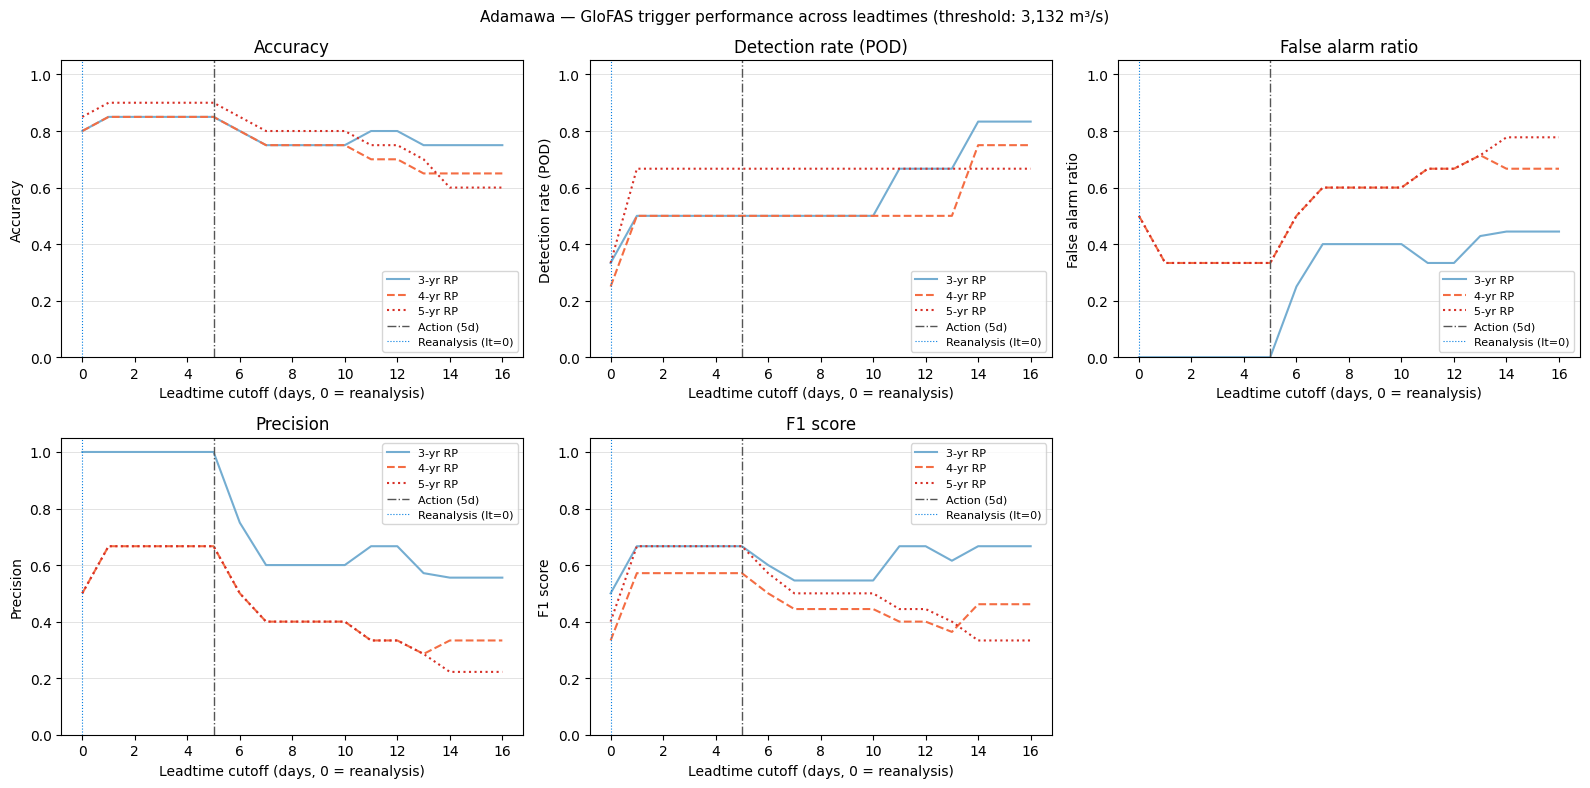

In [8]:
RP_COLORS = {3: "#74ADD1", 4: "#F46D43", 5: "#D73027"}
RP_STYLES = {3: "-", 4: "--", 5: ":"}
METRICS = [
    ("accuracy",       "Accuracy"),
    ("detection_rate", "Detection rate (POD)"),
    ("far",            "False alarm ratio"),
    ("precision",      "Precision"),
    ("f1",             "F1 score"),
]

leadtimes = sorted(df_annual["leadtime"].unique())

lt_records = []
for lt in leadtimes:
    df_lt = evaluate_trigger(df_annual, fs_event_years, RP_LEVELS, THRESH, lt)
    df_lt["leadtime"] = lt
    lt_records.append(df_lt.reset_index())
df_lt_all = pd.concat(lt_records, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

for i, (metric, ylabel) in enumerate(METRICS):
    ax = axes_flat[i]
    for rp in RP_LEVELS:
        df_m = df_lt_all[df_lt_all["fs_rp"] == rp]
        ax.plot(
            df_m["leadtime"], df_m[metric],
            color=RP_COLORS[rp], linestyle=RP_STYLES[rp],
            label=f"{rp}-yr RP",
        )
    for lt_name, lt_val in triggers.items():
        ax.axvline(lt_val, color="#555", linewidth=1, linestyle="-.",
                   label=f"{lt_name} ({lt_val}d)")
    ax.axvline(0, color="#007CE0", linewidth=0.8, linestyle=":", label="Reanalysis (lt=0)")
    ax.set_xlabel("Leadtime cutoff (days, 0 = reanalysis)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)

axes_flat[5].set_visible(False)

fig.suptitle(f"{STATE} — GloFAS trigger performance across leadtimes (threshold: {THRESH:,} m³/s)",
             fontsize=11)
plt.tight_layout()
plt.savefig(
    f"{FIGURES_DIR}/{STATE.lower()}_trigger_summary_performance.png",
    dpi=200, bbox_inches="tight",
)
plt.show()